In [106]:
import pandas as pd 
import numpy as np 

In [107]:
df = pd.read_csv("C:\\Users\\Arnav Singla\\OneDrive\\Desktop\\ailec.csv")

In [108]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [109]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [110]:
import matplotlib.pyplot as plt 

In [111]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [112]:
#handle missing values 
#fill age with median

df['Age'] = df['Age'].fillna(df['Age'].median(),inplace =True)

C:\Users\Arnav Singla\AppData\Local\Temp\ipykernel_33736\3235088214.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(df['Age'].median(),inplace =True)


In [113]:
df = df.drop(columns=['PassengerId','Name','Ticket','Cabin'])

In [114]:
df.isnull().sum()


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [115]:
df['Embarked'].mode()[0]

'S'

In [116]:
df['Embarked'] = df['Embarked'].fillna('S')

In [117]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [118]:
df.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object

In [119]:
#label encode string columns 
from sklearn.preprocessing import  LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [120]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S
5,0,3,1,28.0,0,0,8.4583,Q
6,0,1,1,54.0,0,0,51.8625,S
7,0,3,1,2.0,3,1,21.0750,S
8,1,3,0,27.0,0,2,11.1333,S
9,1,2,0,14.0,1,0,30.0708,C


In [121]:
#one hot encode embarked 
df = pd.get_dummies(df,columns=['Embarked'],drop_first=True)

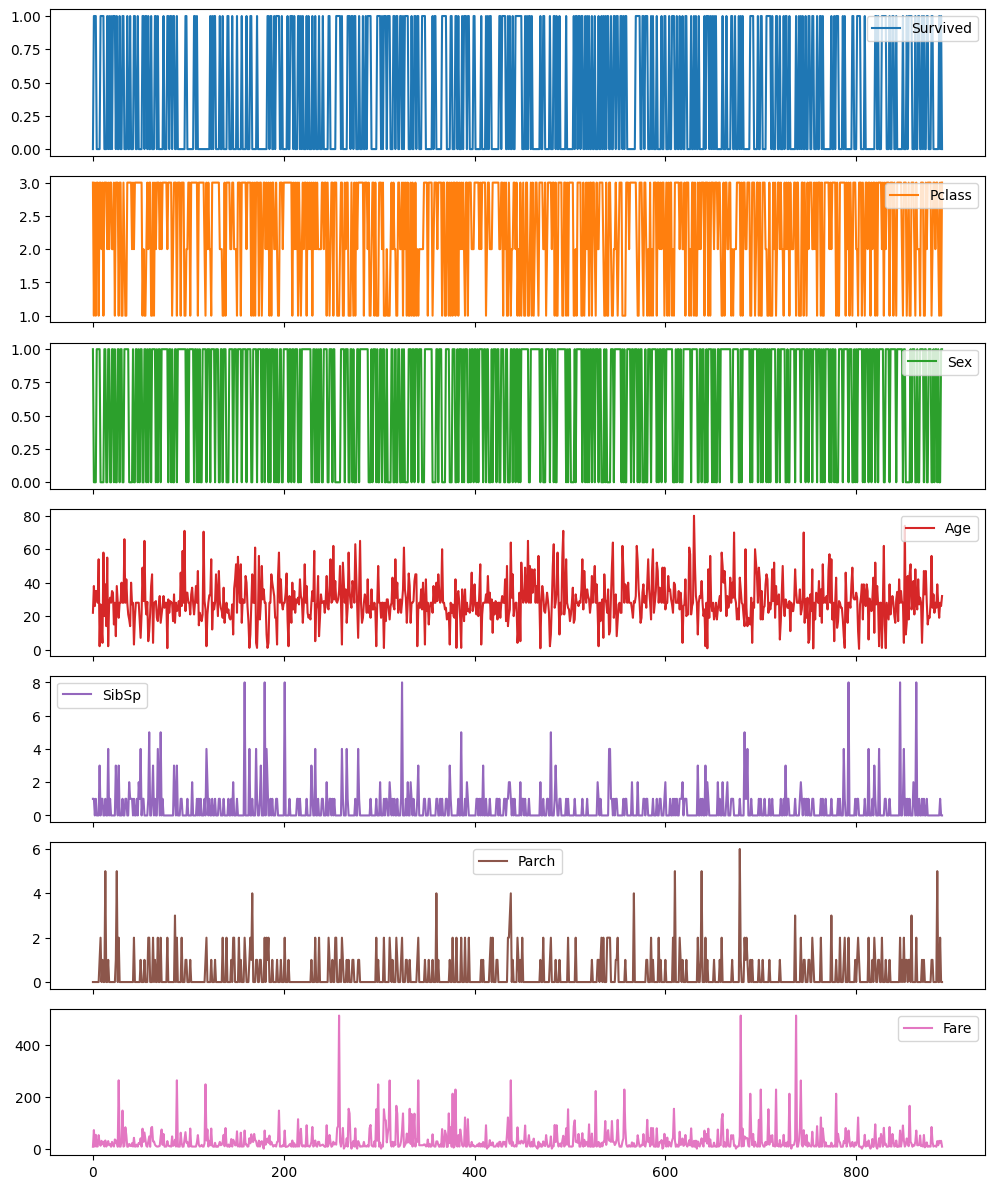

In [122]:
df.plot(subplots=True, figsize= (10,12),layout=(-1,1))
plt.tight_layout()
plt.show()

In [123]:
#Handling Outliers -> no outliers

In [124]:
#create new feature 
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1


In [125]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize
0,0,3,1,22.0,1,0,7.2500,False,True,2
1,1,1,0,38.0,1,0,71.2833,False,False,2
2,1,3,0,26.0,0,0,7.9250,False,True,1
3,1,1,0,35.0,1,0,53.1000,False,True,2
4,0,3,1,35.0,0,0,8.0500,False,True,1


In [126]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = df.drop('Survived',axis=1)
y = df['Survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)


In [127]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df['Fare'] = np.log1p(df['Fare'])

num_cols = ['Age','Fare','FamilySize','SibSp','Parch','Pclass']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [129]:
#train after scaling 
model = LogisticRegression()
model.fit(X_train,y_train)
predictions = model.predict(X_test)

In [133]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print(accuracy_score(y_test,predictions))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

0.7877094972067039
[[90 19]
 [19 51]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       109
           1       0.73      0.73      0.73        70

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

